## Содержание

1. Знакомство с данными
2. Предобработка данных
3. Инжиниринг признаков
4. Классификация компаний на массовые, средние и нишевые сегменты
5. Работа с выбросами и анализ
6. Определение границ рассматриваемого периода и фильтрация аномалий
7. Анализ типов финансирования по объёму и популярности
8. Анализ динамики привлеченных средств по годам
9. Анализ динамики размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
10. Годовая динамика возвращенных средств по типам финансирования
11. Итоговый вывод и рекомендации

In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

## 1. Знакомство с данными

In [264]:
# Загружаем датафрейм df_investments

df_investments = pd.read_csv('/Users/ekaterinaproshenkova/Downloads/cb_investments.csv', sep=';')
display (df_investments)

/var/folders/rn/5jytj9g92fjb7xsb83sdr_2h0000gn/T/ipykernel_8326/3896143868.py:3: DtypeWarning: Columns (0: founded_at, 1: founded_month, 2: founded_quarter) have mixed types. Specify dtype option on import or set low_memory=False.
  df_investments = pd.read_csv('/Users/ekaterinaproshenkova/Downloads/cb_investments.csv', sep=';')


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [265]:
df_investments.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

In [266]:
# Проверяю долю пропусков в каждом столбце датасета df_investments

df_investments.isnull().sum()/len(df_investments)*100

name                     8.945740
homepage_url            15.296350
category_list           16.239363
 market                 16.239363
 funding_total_usd       8.943898
status                  11.364055
country_code            18.655837
state_code              44.448742
region                  18.655837
city                    20.208494
funding_rounds           8.943898
participants            43.874093
founded_at              28.990312
founded_month           29.122923
founded_quarter         29.122923
founded_year            28.990312
first_funding_at         8.943898
mid_funding_at          44.214830
last_funding_at          8.943898
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt 

__Промежуточный вывод по датафрейму df_investments:__
1. Привести тип данных у следующих столбцов к:
- funding_total_usd -- float
- funding_rounds -- int
- participants -- int
- founded_at -- date
- founded_month -- date
- founded_quarter -- date
- founded_year -- date
- first_funding_at -- date
- last_funding_at -- date
2. Убрать лишние пробелы в названиях столбцов
3. Привести названия столбцов к стилю snake_case

In [267]:
# Загружаем датафрейм df_returns

df_returns = pd.read_csv('/Users/ekaterinaproshenkova/Downloads/cb_returns.csv')
display(df_returns)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [268]:
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


__Для оптимизации дальнейшей работы сделаю столбец 'year' в датафрейме df_returns индексом всего датасета__

In [269]:
df_returns = df_returns.set_index('year')

__Промежуточный вывод по датафрейму df_returns:__

Типы данных корректны, пропусков нет.

## 2. Предобработка данных

In [270]:
# Выводим названия столбцов обоих датафреймов

print(df_investments.columns.tolist())
print(df_returns.columns.tolist())

['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']
['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


In [271]:
# В датафрейме df_investments убираю лишние пробелы и подчеркивания по краям. Привожу названия столбцов к единому стилю snake_case

df_investments.columns = df_investments.columns.str.strip('_ ')
df_investments.columns = df_investments.columns.str.lower()
print(df_investments.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='str')


In [272]:
# Преобразовываем funding_total_usd к числовому типу float

df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'].str.replace(',', ''), errors='coerce')
print(df_investments.info())

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3   market                45477 non-null  str    
 4   funding_total_usd     40907 non-null  float64
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

In [ ]:
# Заполняю значением -1 пропуски в столбцах funding_rounds и participants чтобы привести к int без ошибки
df_investments['funding_rounds'] = np.ceil(df_investments['funding_rounds'].fillna(-1)).astype(int)
df_investments['participants'] = np.ceil(df_investments['participants'].fillna(-1)).astype(int)

# Привожу funding_rounds и participants к типу данных int 
df_investments['funding_rounds'] = df_investments['funding_rounds'].round(0).astype(int)
df_investments['participants'] = df_investments['participants'].round(0).astype(int)

# Проверяю тип данных
print(df_investments[['funding_rounds', 'participants']].dtypes)

funding_rounds    int64
participants      int64
dtype: object


In [274]:
df_investments[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']]

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06
1,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15
2,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14
...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [275]:
# Полные даты (YYYY-MM-DD)
full_date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
for col in full_date_cols:
    df_investments[col] = pd.to_datetime(df_investments[col], format='%Y-%m-%d', errors='coerce')

# founded_month приведу к datetime (первое число месяца)
df_investments['founded_month'] = pd.to_datetime(df_investments['founded_month'], format='%Y-%m', errors='coerce')

# founded_quarter 
df_investments['founded_quarter'] = pd.to_datetime(df_investments['founded_quarter'], format='%Y-%m-%d', errors='coerce')

# founded_year преобразую в int, чтобы отображался только год (для этого заменю пропуски на -1)
df_investments['founded_year'] = df_investments['founded_year'].fillna(-1).astype(int)

df_investments.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  str           
 1   homepage_url          45989 non-null  str           
 2   category_list         45477 non-null  str           
 3   market                45477 non-null  str           
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  str           
 6   country_code          44165 non-null  str           
 7   state_code            30161 non-null  str           
 8   region                44165 non-null  str           
 9   city                  43322 non-null  str           
 10  funding_rounds        54294 non-null  int64         
 11  participants          54294 non-null  int64         
 12  founded_at            38554 non-null  datetime64[us]
 13  founded_month         38482

### Работа с пропусками и дубликатами

__Нахожу и обрабатываю пропуски в текстовых столбцах__

In [ ]:
# Нахожу пропуски в текстовых столбцах
text_cols = df_investments.select_dtypes(include=['str']).isna().sum()
print(text_cols)

name              4857
homepage_url      8305
category_list     8817
market            8817
status            6170
country_code     10129
state_code       24133
region           10129
city             10972
dtype: int64


In [277]:
# Удаляю пропуски в столбце "name". Нет смысла ставить заглушку, нам важна информация в этом поле
df_investments = df_investments.dropna (subset=['name'])

# Выбираю текстовые столбцы, исключая 'name', так как пропуски уже удалены
text_cols = df_investments.select_dtypes(include=['str']).columns
cols_to_fill = [col for col in text_cols if col != 'name']

# Заменяю пропуски на 'Unknown'
df_investments[cols_to_fill] = df_investments[cols_to_fill].fillna('Unknown')

__Нахожу и обрабатываю пропуски в числовых столбцах__

In [278]:
df_investments.isnull().sum()/len(df_investments)*100

name                      0.000000
homepage_url              0.000000
category_list             0.000000
market                    0.000000
funding_total_usd        17.256306
status                    0.000000
country_code              0.000000
state_code                0.000000
region                    0.000000
city                      0.000000
funding_rounds            0.000000
participants              0.000000
founded_at               22.015899
founded_month            22.161539
founded_quarter         100.000000
founded_year              0.000000
first_funding_at          0.000000
mid_funding_at           38.734146
last_funding_at           0.000000
seed                      0.000000
venture                   0.000000
equity_crowdfunding       0.000000
undisclosed               0.000000
convertible_note          0.000000
debt_financing            0.000000
angel                     0.000000
grant                     0.000000
private_equity            0.000000
post_ipo_equity     

In [279]:
# Строки с пропусками в столбце 'funding_total_usd' удаляю, так как информация важна для анализа, в пустых строках ценности нет
df_investments = df_investments.dropna(subset=['funding_total_usd'])

# Заменяем пропуски в остальных столбцах значением -1.
# 'funding_total_usd' и 'mid_funding_at' не трогаю, так как пропуски в 'funding_total_usd' удалены, а 'mid_funding_at' найду значение вручную

exclude_cols = ['funding_total_usd', 'mid_funding_at']

for col in df_investments.columns:
    # Исправлено условие: используем 'and'
    if col not in exclude_cols:
        df_investments[col] = df_investments[col].fillna(-1)


__Пропуски в значениях mid_funding_at заполню на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения вместо пропусков возьму приблизительно середину интервала между этими двумя датами.__

In [280]:
# Нахожу среднее значение между двумя датами
mask = df_investments['mid_funding_at'].isna() & \
       df_investments['first_funding_at'].notna() & \
       df_investments['last_funding_at'].notna()

# Вычисляю среднюю дату между first_funding_at и last_funding_at
df_investments.loc[mask, 'mid_funding_at'] = (
    df_investments.loc[mask, 'first_funding_at'] + 
    (df_investments.loc[mask, 'last_funding_at'] - df_investments.loc[mask, 'first_funding_at']) / 2
)

## 3. Инжиниринг признаков

Разобью все компании на три группы:
- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

Визуализирую соотношение этих групп, создав два графика

По количеству компаний: 
- процент от общего числа компаний (к каждой из трёх групп)
- объём инвестиций: доля от общего объёма привлечённых для каждой группы.

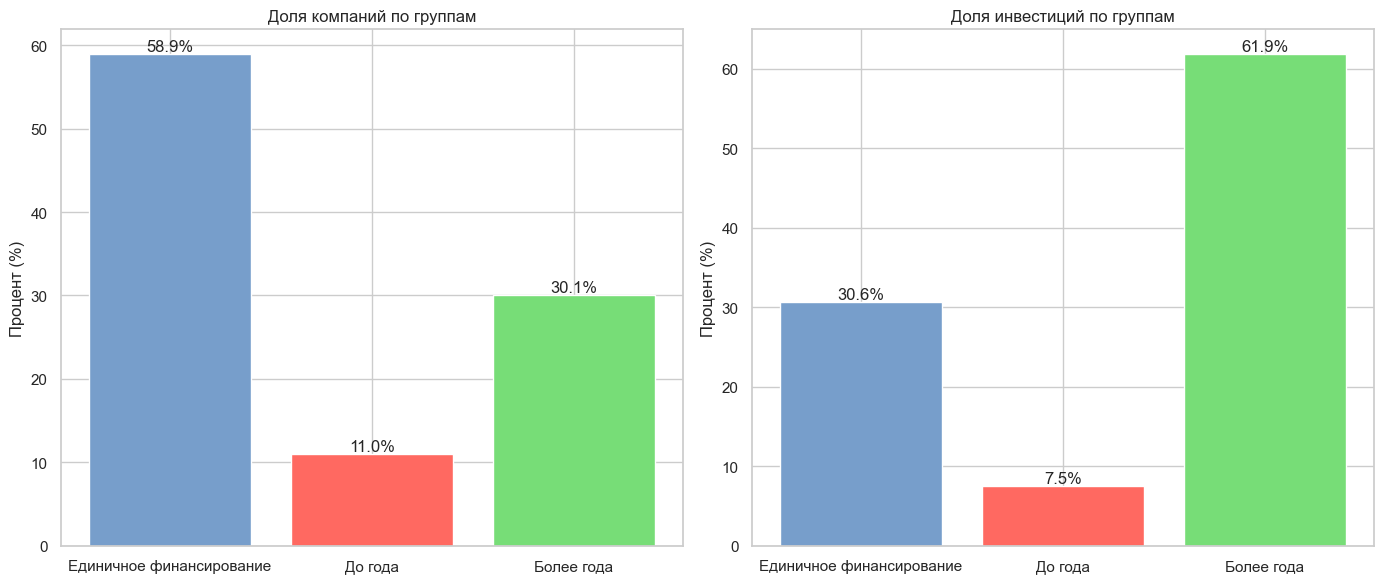

                          companies_pct  investments_pct
group                                                   
Единичное финансирование      58.944898        30.618234
До года                       11.003276         7.510132
Более года                    30.051826        61.871633


In [ ]:
# Вычисляю длительность финансирования в днях
df_investments['funding_days'] = (df_investments['last_funding_at'] - df_investments['first_funding_at']).dt.days

# Группирую компании
def assign_group (row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_days'] <= 365:
        return 'До года'
    else:
        return 'Более года'

df_investments['group'] = df_investments.apply(assign_group, axis=1)

# Считаю результаты по группам
result = df_investments.groupby('group').agg(
    companies=('name', 'count'),
    investments=('funding_total_usd', 'sum')
)

# Нахожу долю в процентах
result['companies_pct'] = result['companies'] / result['companies'].sum() * 100
result['investments_pct'] = result['investments'] / result['investments'].sum() * 100

# Задаю нужный порядок отображения категорий
desired_order = ['Единичное финансирование', 'До года', 'Более года']
result = result.reindex(desired_order)

# Визуализация
cfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#779ecb', '#ff6961', '#77dd77']

# Столбчатая диаграмма по количеству компаний
bars1 = ax1.bar(result.index, result['companies_pct'], color=colors)
ax1.set_title('Доля компаний по группам')
ax1.set_ylabel('Процент (%)')
ax1.bar_label(bars1, fmt='%.1f%%')

# Столбчатая диаграмма по объему инвестиций
bars2 = ax2.bar(result.index, result['investments_pct'], color=colors)
ax2.set_title('Доля инвестиций по группам')
ax2.set_ylabel('Процент (%)')
ax2.bar_label(bars2, fmt='%.1f%%')

plt.tight_layout()
plt.show()

print(result[['companies_pct', 'investments_pct']])

ВЫВОД: 

Большинство компаний (58,9%) получают единичное финансирование. Финансируются в течение 1 года - 11% компаний и 30,1% получают финансирование более года. 

Больше всего инвестиций получили компании, у которых финансирование более 1 года (61,9% всех средств), 30,6% от всех средств получили компании с единичным финансированием. И лишь 7,5% от всех средств получили компании, которые финансировались в течение 1 года.

В категории до 1 года меньше всего компаний (11%) и самый маленький объём финансирования (7,5%)



## 4. Классификация компаний на массовые, средние и нишевые сегменты рынка

- Массовые: боле 120 компаний
- Средние: от 35 до 120 компаний
- Нишевые: до 35 компаний

market
 Software                   4190
 Biotechnology              3531
Unknown                     2503
 Mobile                     1852
 E-Commerce                 1528
                            ... 
Data Security                  1
 Consumer Goods                1
 Musicians                     1
 Location Based Services       1
 Gold                          1
Name: count, Length: 849, dtype: int64
Массовые сегменты: 54
Средние сегменты: 81
Нишевые сегменты: 714


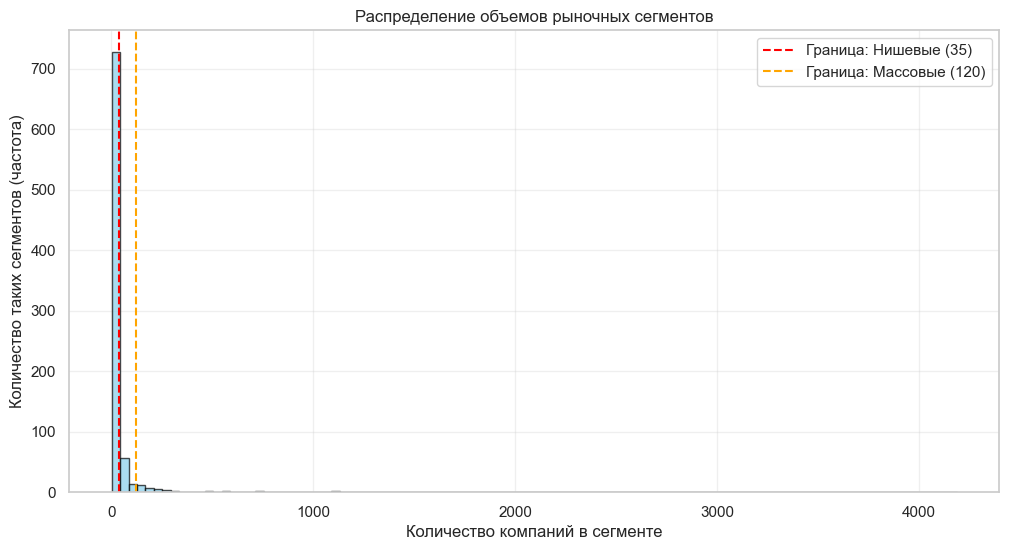

In [282]:
# Проверяю количество компаний в каждом сегменте
market_counts = df_investments['market'].value_counts()
print(market_counts)

# Выделяю сегменты
niche = market_counts[market_counts < 35]
mid = market_counts[market_counts.between(35, 120)]
market = market_counts[market_counts > 120]

# Вывожу статистику
print(f"Массовые сегменты: {len(market)}")
print(f"Средние сегменты: {len(mid)}")
print(f"Нишевые сегменты: {len(niche)}")

# Вывожу график
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(market_counts, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

# Добавляю линию разграничения
ax.axvline(x=35, color='red', linestyle='--', label='Граница: Нишевые (35)')
ax.axvline(x=120, color='orange', linestyle='--', label='Граница: Массовые (120)')

ax.set_xlabel('Количество компаний в сегменте')
ax.set_ylabel('Количество таких сегментов (частота)')
ax.set_title('Распределение объемов рыночных сегментов')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

В столбце market оставлю только массовые сегменты. Для остальных сегментов заменю значения на заглушки — niche для нишевых и mid для средних.

Дальнейшие исследования выполню с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

In [ ]:
# Создаю словарь для замены: массовые сегменты остаются как есть, остальные заменяю
replacement_dict = {}
for segment, count in market_counts.items():
    if count > 120:
        replacement_dict[segment] = segment
    elif count >= 35:
        replacement_dict[segment] = 'mid'
    else:
        replacement_dict[segment] = 'niche'

# Заменяю значения в столбце market
df_investments['market'] = df_investments['market'].map(replacement_dict)

print(df_investments['market'].value_counts())

market
mid                       5069
 Software                 4190
 Biotechnology            3531
Unknown                   2503
niche                     2494
 Mobile                   1852
 E-Commerce               1528
 Curated Web              1404
 Enterprise Software      1190
 Health Care              1128
 Clean Technology         1094
 Hardware + Software      1008
 Games                     986
 Advertising               954
 Health and Wellness       825
 Social Media              787
 Education                 736
 Finance                   728
 Analytics                 565
 Manufacturing             564
 Security                  491
 Semiconductors            473
 Web Hosting               400
 Consulting                322
 Hospitality               313
 Travel                    293
 Fashion                   285
 News                      284
 Messaging                 264
 Real Estate               251
 Music                     246
 Search                    242
S

Комментарий: все компании относятся к массовым. Ни в одной нише не было меньше 120 компаний.

## 5. Работа с выбросами и анализ

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу funding_total_usd графическим образом оценю, какой размер общего финансирования для одной компании будет типичным, а какой выбивающимся. Найду интервал, в котором лежат типичные значения.

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Всего компаний: 40,906
Мин: $1
Макс: $30,079,503,000
Медиана: $2,000,000
Среднее: $15,912,914


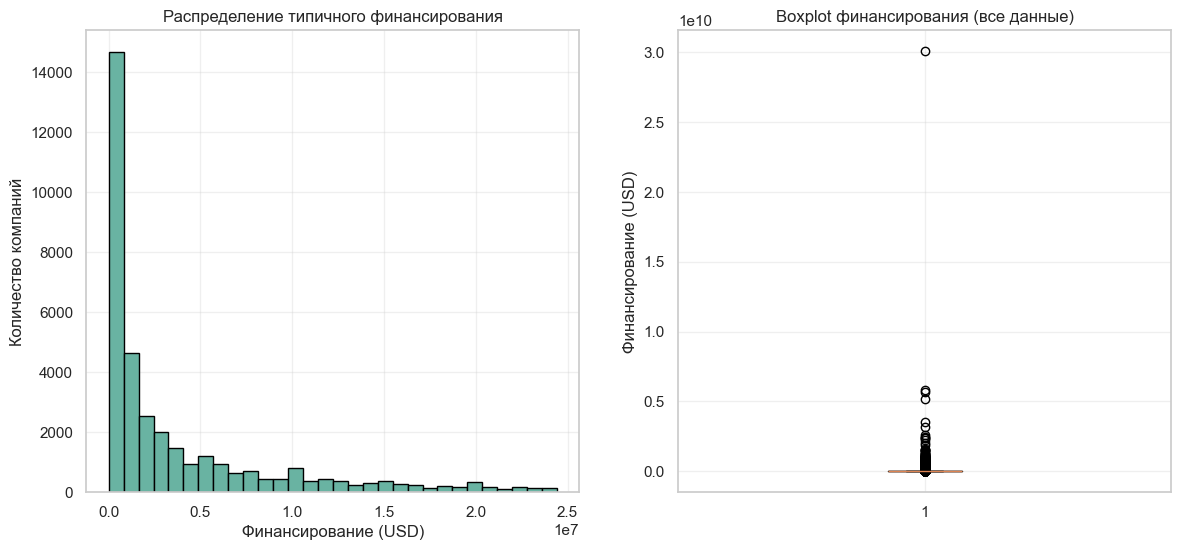

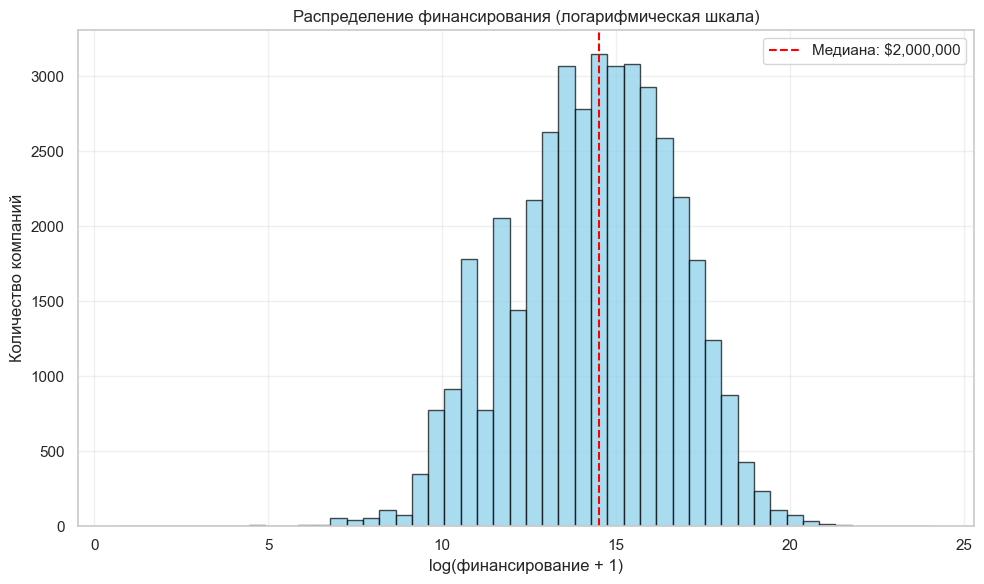

In [284]:
# Для удобства сохраним колонку в переменную
col = 'funding_total_usd'
funding_data = df_investments[col]

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Всего компаний: {len(df_investments):,}")
print(f"Мин: ${funding_data.min():,.0f}")
print(f"Макс: ${funding_data.max():,.0f}")
print(f"Медиана: ${funding_data.median():,.0f}")
print(f"Среднее: ${funding_data.mean():,.0f}")

# Расчет типичного интервала
Q1 = funding_data.quantile(0.25)
Q3 = funding_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# Фильтрация
typical_data = df_investments[
    (funding_data >= lower_bound) & (funding_data <= upper_bound)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма типичных данных
ax1.hist(typical_data[col], bins=30, edgecolor='black', color='#69b3a2')
ax1.set_xlabel('Финансирование (USD)')
ax1.set_ylabel('Количество компаний')
ax1.set_title('Распределение типичного финансирования')
ax1.grid(True, alpha=0.3)

# Boxplot
ax2.boxplot(funding_data)
ax2.set_ylabel('Финансирование (USD)')
ax2.set_title('Boxplot финансирования (все данные)')
ax2.grid(True, alpha=0.3)

# Рассчитываю логарифм и медиану для графика
log_funding = df_investments['funding_total_usd'].apply(lambda x: math.log(x + 1))
median_log = math.log(stats['50%'] + 1)

# Визуализация
plt.figure(figsize=(10, 6))
plt.hist(log_funding, bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# Линия медианы
plt.axvline(median_log, color='red', linestyle='--', 
            label=f'Медиана: ${stats["50%"]:,.0f}')

plt.title('Распределение финансирования (логарифмическая шкала)')
plt.xlabel('log(финансирование + 1)')
plt.ylabel('Количество компаний')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__Промежуточный вывод__: 
большинство компаний получает финансирование около 15 млн долл. В данных есть сильные выбросы, о чем свидетельствует boxplot и большая разница между медианой и средним значением.

In [285]:

# Группирую данные и применяю функцию для расчета границ и фильтрации
def calculate_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Фильтрую выбросы
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    
    total_count = len(group)
    outliers_count = len(outliers)
    
    return pd.Series({
        'total_companies': total_count,
        'outlier_companies': outliers_count,
        'outlier_ratio': (outliers_count / total_count * 100) if total_count > 0 else 0
    })

(
    df_investments.groupby('market')['funding_total_usd']
    .apply(calculate_outliers)
    .unstack()
    .reset_index()
)

# Сортировка
df_sorted = df_results.sort_values('outlier_ratio', ascending=False)

print("Топ сегментов с наибольшей долей выбросов:")
print(df_sorted.head(10))


Топ сегментов с наибольшей долей выбросов:
               market  total_companies  outlier_companies  outlier_ratio
34       Real Estate             251.0               45.0      17.928287
45        Technology             229.0               37.0      16.157205
36            Search             242.0               39.0      16.115702
14     Entertainment             137.0               22.0      16.058394
51           Software            137.0               22.0      16.058394
7    Cloud Computing             131.0               21.0      16.030534
4           Big Data             140.0               22.0      15.714286
35              SaaS             224.0               35.0      15.625000
49        E-Commerce             129.0               20.0      15.503876
46            Travel             293.0               45.0      15.358362


__Промежуточный вывод__: больше всего выбросов обнаружено в сегментах Real Estate, Technology, Search.

## 6. Определение границ рассматриваемого периода и фильтрация аномалий

Проверяю по датасету что данные за 2014 год полные. Затем исключу из датасета компании с аномальным финансированием.

После исключения аномальных записей, на основе столбцов mid_funding_at и funding_rounds оставлю в датасете данные только об определённых компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [286]:
print("--- Проверка данных за 2014 год ---")
print(f"Всего записей в датасете: {len(df_investments)}")

# Исключаю компании с аномальным финансированием методом IQR
Q1 = df_investments['funding_total_usd'].quantile(0.25)
Q3 = df_investments['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

df_normal = df_investments[
    df_investments['funding_total_usd'].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
].copy()

print(f"Записей после исключения выбросов: {len(df_normal)}")


--- Проверка данных за 2014 год ---
Всего записей в датасете: 40906
Записей после исключения выбросов: 35674


In [287]:
# Преобразую столбец в строку и извлекаю год
df_normal.loc[:, 'funding_year'] = df_normal['mid_funding_at'].astype(str)

# Считаю количество раундов по годам
rounds_per_year = df_normal.groupby('funding_year')['funding_rounds'].sum()

# Определяю годы с 50+ раундами
years_with_50_plus_rounds = rounds_per_year[rounds_per_year >= 50].index

print(f"Годы с 50+ раундами финансирования: {list(years_with_50_plus_rounds)}")

# Фильтрую компании по этим годам
df_final = df_normal[df_normal['funding_year'].isin(years_with_50_plus_rounds)]

print(f"Итоговое количество записей: {len(df_final)}")

Годы с 50+ раундами финансирования: ['2005-01-01 00:00:00', '2006-01-01 00:00:00', '2006-12-01 00:00:00', '2007-01-01 00:00:00', '2007-02-01 00:00:00', '2007-03-01 00:00:00', '2007-04-01 00:00:00', '2007-05-01 00:00:00', '2007-06-01 00:00:00', '2007-07-01 00:00:00', '2007-08-01 00:00:00', '2007-09-01 00:00:00', '2007-10-01 00:00:00', '2007-11-01 00:00:00', '2007-12-01 00:00:00', '2008-01-01 00:00:00', '2008-02-01 00:00:00', '2008-03-01 00:00:00', '2008-04-01 00:00:00', '2008-05-01 00:00:00', '2008-06-01 00:00:00', '2008-07-01 00:00:00', '2008-08-01 00:00:00', '2008-09-01 00:00:00', '2009-01-01 00:00:00', '2009-04-01 00:00:00', '2009-05-01 00:00:00', '2009-06-01 00:00:00', '2009-07-01 00:00:00', '2009-08-01 00:00:00', '2009-09-01 00:00:00', '2009-10-01 00:00:00', '2009-11-01 00:00:00', '2009-12-01 00:00:00', '2009-12-15 00:00:00', '2010-01-01 00:00:00', '2010-01-05 00:00:00', '2010-02-01 00:00:00', '2010-03-01 00:00:00', '2010-04-01 00:00:00', '2010-05-01 00:00:00', '2010-06-01 00:00:00

__Промежуточный вывод__: всего 9034 компаний получали финансирование в годы, когда было зафиксировано более 50 раундов.

## 7. Анализ типов финансирования по объёму и популярности

Построю график, который покажет какие типы финансирования в сумме привлекли больше всего денег. Буду ориентироваться на значения в столбцах seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market и product_crowdfunding.

Также построю график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравню графики и выделю часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

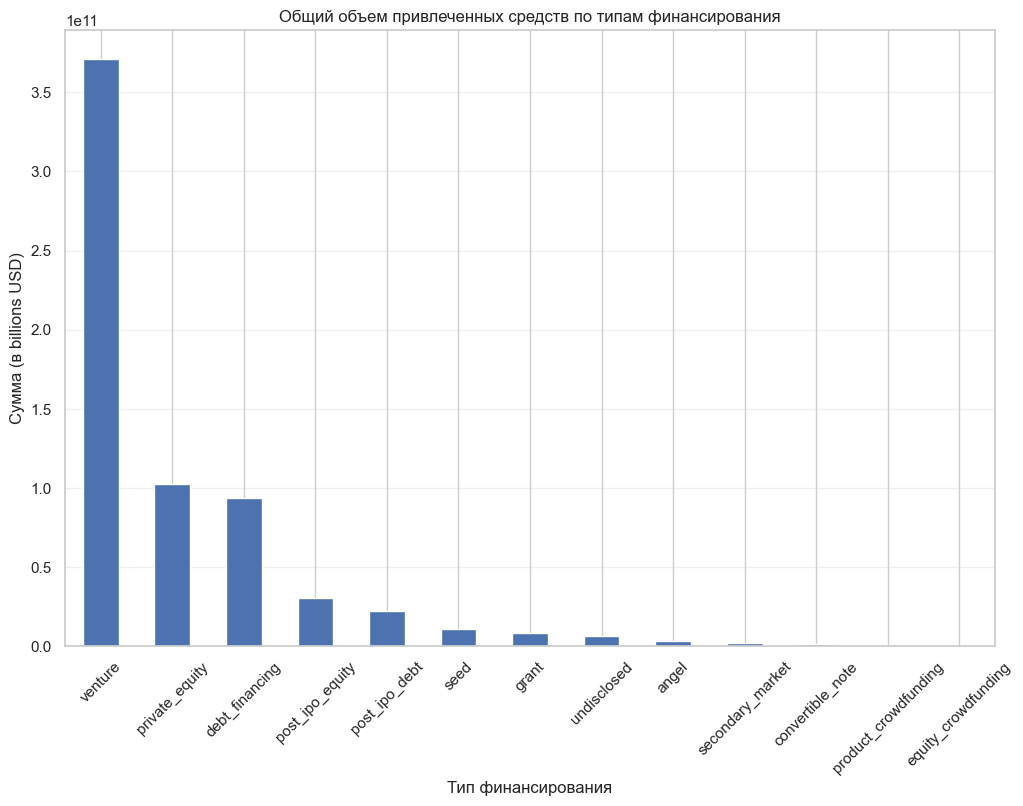

Общие объемы финансирования по типам (USD):
venture: $370,836,936,410.00
private_equity: $102,548,538,864.00
debt_financing: $93,346,700,426.00
post_ipo_equity: $30,101,495,486.00
post_ipo_debt: $21,922,587,681.00
seed: $10,743,915,148.00
grant: $8,050,744,787.00
undisclosed: $6,437,879,696.00
angel: $3,234,183,511.00
secondary_market: $1,901,183,890.00
convertible_note: $1,155,074,287.00
product_crowdfunding: $349,735,639.00
equity_crowdfunding: $304,702,319.00


In [288]:
# Список столбцов с типами финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Суммирую общие объемы по каждому типу финансирования
funding_totals = df_investments[funding_types].sum()

# Сортирую по убыванию
funding_totals_sorted = funding_totals.sort_values(ascending=False)

# Вывожу график
plt.figure(figsize=(12, 8))
funding_totals_sorted.plot(kind='bar')
plt.title('Общий объем привлеченных средств по типам финансирования')
plt.ylabel('Сумма (в billions USD)')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Вывожу численные значения для справки
print("Общие объемы финансирования по типам (USD):")
for funding_type, total in funding_totals_sorted.items():
    print(f"{funding_type}: ${total:,.2f}")

__Промежуточный вывод:__ самое крупное финансирование привлекли трисегмента: venture, private_equity, debt_financing. Но venture идет с большим отрывом (более 3,5 млрд долл).

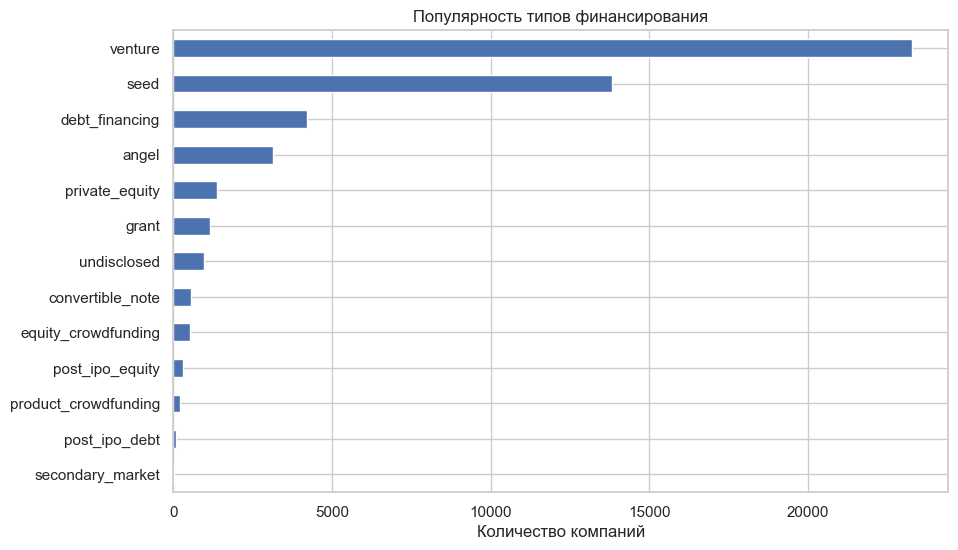

Популярность и объемы финансирования:
seed: 13839 компаний, 10.7 млрд USD
venture: 23277 компаний, 370.8 млрд USD
equity_crowdfunding: 522 компаний, 0.3 млрд USD
undisclosed: 952 компаний, 6.4 млрд USD
convertible_note: 557 компаний, 1.2 млрд USD
debt_financing: 4225 компаний, 93.3 млрд USD
angel: 3129 компаний, 3.2 млрд USD
grant: 1142 компаний, 8.1 млрд USD
private_equity: 1373 компаний, 102.5 млрд USD
post_ipo_equity: 316 компаний, 30.1 млрд USD
post_ipo_debt: 75 компаний, 21.9 млрд USD
secondary_market: 19 компаний, 1.9 млрд USD
product_crowdfunding: 213 компаний, 0.3 млрд USD


In [289]:
# Список типов финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Считаю популярность типов финансирования (количество ненулевых значений)
popularity = (df_investments[funding_types] > 0).sum()

# График популярности
plt.figure(figsize=(10, 6))
popularity.sort_values().plot(kind='barh')
plt.title('Популярность типов финансирования')
plt.xlabel('Количество компаний')
plt.show()

# Считаю общие объемы финансирования
totals = df_investments[funding_types].sum()

# Сравниваю популярность и объемы
print("Популярность и объемы финансирования:")
for fund_type in funding_types:
    print(f"{fund_type}: {popularity[fund_type]} компаний, {totals[fund_type]/1e9:.1f} млрд USD")


__Промежуточный вывод:__ больше всего было проинвестировано в венчур и по объёму средств и по количеству компаний.На втором месте по объёму привлеченных средств сумма инвестиций в виде прямых (частных) вложений (private_equity). Меньше всего по объему привлеченных средств сумма сделок на втричном рынке (secondary_market). Краудфандинг (product_crowdfunding) является наименее популярным.

__Проверяю суммарный объём возвратов от разных типов финансирования за весь период. Данные беру из дополнительного датасета df_returns__

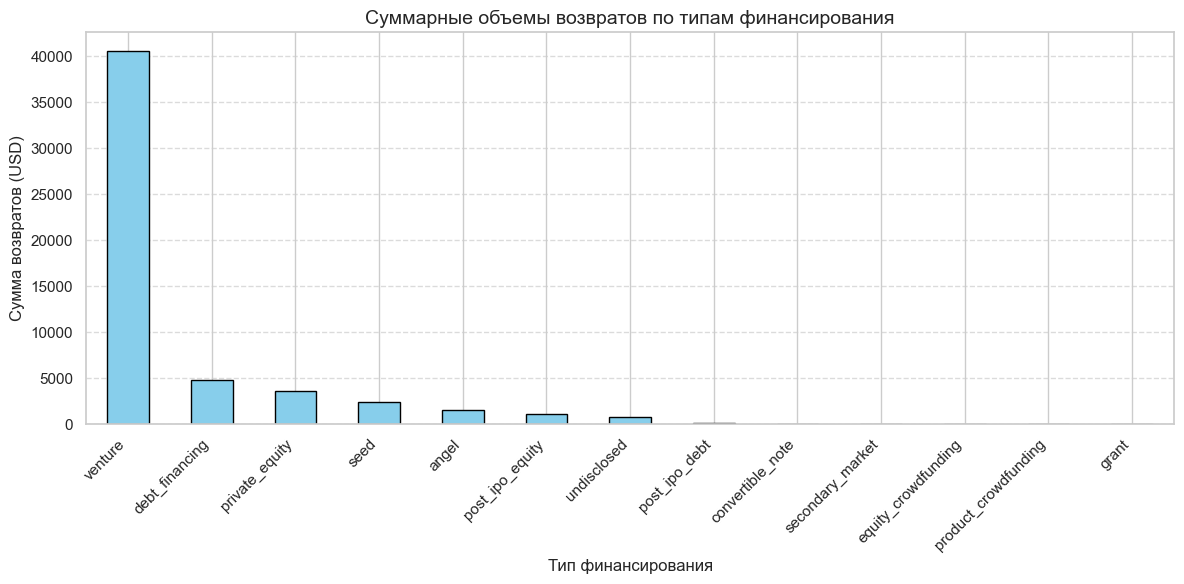

Суммарные объемы возвратов по типам финансирования:
venture                 $40,578.62
debt_financing           $4,734.85
private_equity           $3,587.33
seed                     $2,382.24
angel                    $1,509.23
post_ipo_equity          $1,104.96
undisclosed                $730.88
post_ipo_debt               $91.03
convertible_note            $34.79
secondary_market             $5.20
equity_crowdfunding          $3.83
product_crowdfunding         $1.86
grant                        $0.00
dtype: str


In [290]:
# Список типов финансирования из df_returns
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Суммирую и сортирую возвраты для каждого типа
total_returns = df_returns[return_types].sum().sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 6))
total_returns.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Суммарные объемы возвратов по типам финансирования', fontsize=14)
plt.ylabel('Сумма возвратов (USD)')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Суммарные объемы возвратов по типам финансирования:")
print(total_returns.map('${:,.2f}'.format))


__Промежуточный вывод:__ самый большой возврат инвестиций по сегменту venture, но нужно помнить, что и сумма вложенных средств была больше 3,5 млрд и шла с большим отрывом от других видов инвестиций. на втором месте по возврату инвестиций debt_financing, хотя по объёму вложенных средств идет на третьем месте, после private_equity. На третьем месте по объёму возвратов - private_equity. Было бы неплохо посчитать по этим трем сегментам долю возвратов к инвестированной сумме и сравнить между собой, но пока debt_financing выглядит более устойчивым в плане возвратов.

## 8. Анализ динамики привлеченных средств по годам

Используя столбцы funding_total_usd и funding_rounds, рассчитаю для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построю графики, отражающие:

- динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования

- динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


На основе полученных данных получим ответы на вопросы:

В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [291]:
# Расчёт среднего объёма одного раунда для каждой компании

df_investments['avg_funding_per_round'] = df_investments['funding_total_usd'] / df_investments['funding_rounds']
display(df_investments[['name', 'funding_total_usd', 'funding_rounds', 'avg_funding_per_round']].head(15))

,name,funding_total_usd,funding_rounds,avg_funding_per_round
0,Harvard University,90000000.0,1,9.000000e+07
1,University of New Brunswick,2000000.0,1,2.000000e+06
2,DuPont,9000000.0,1,9.000000e+06
3,University of Michigan,7700000.0,3,2.566667e+06
4,Case Western Reserve University,540000.0,1,5.400000e+05
5,Xavier University,19000000.0,1,1.900000e+07
6,Tulane University,12000000.0,4,3.000000e+06
7,Duke University,8700000.0,1,8.700000e+06
8,"Virginia Commonwealth University, Richmond",6000000.0,1,6.000000e+06
9,WeGame,3500000.0,2,1.750000e+06


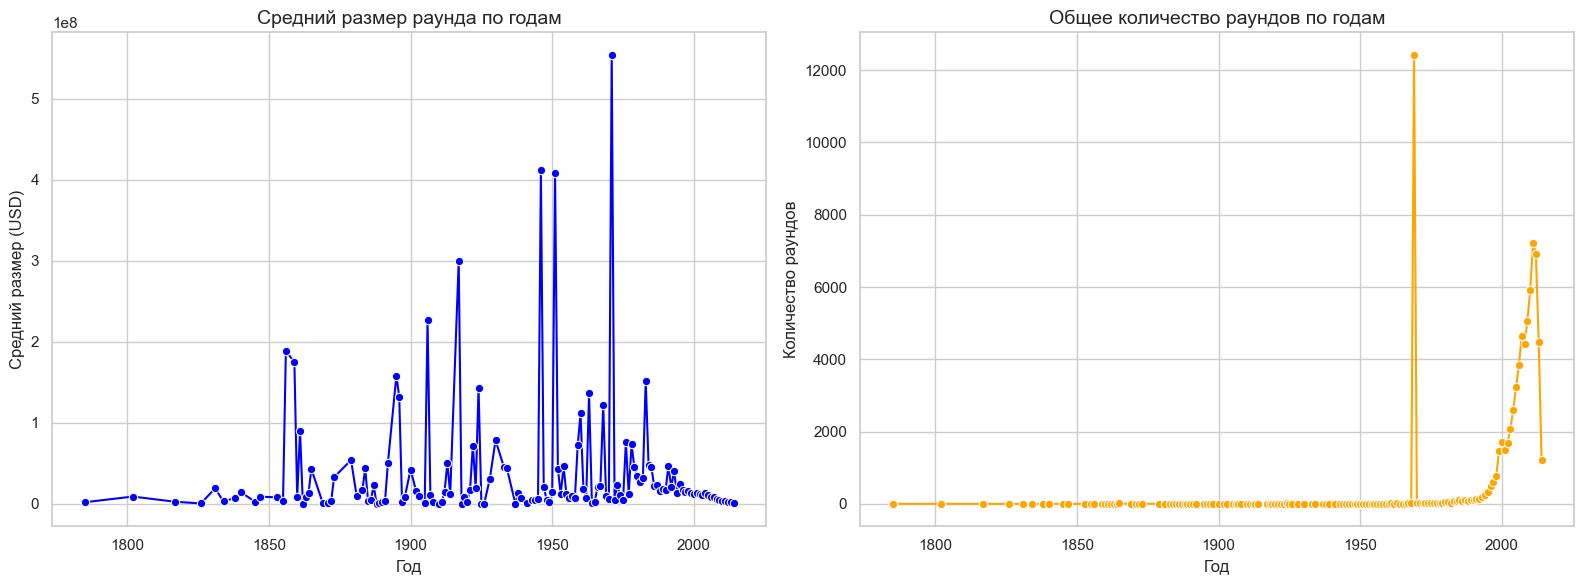

Макс. средний размер раунда: $554,320,433 в 1971 году
В 2014 году: 1225 раундов ср. размер $1,622,606


In [292]:
# Извлекаю год из даты основания компании для анализа по годам
df_investments['founded_at'] = pd.to_datetime(df_investments['founded_at'], errors='coerce')
df_investments['founded_year'] = df_investments['founded_at'].dt.year

# Группирую по году и считаю средний размер раунда и количество раундов
yearly_stats = df_investments.groupby('founded_year').agg({
    'avg_funding_per_round': 'mean',
    'funding_rounds': 'sum'
}).reset_index()

# Визуализация
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1. Средний размер раунда по годам
sns.lineplot(data=yearly_stats, x='founded_year', y='avg_funding_per_round', 
             marker='o', ax=axes[0], color='blue')
axes[0].set_title('Средний размер раунда по годам', fontsize=14)
axes[0].set_ylabel('Средний размер (USD)')
axes[0].set_xlabel('Год')

# График 2: Общее количество раундов
sns.lineplot(data=yearly_stats, x='founded_year', y='funding_rounds', 
             marker='o', ax=axes[1], color='orange')
axes[1].set_title('Общее количество раундов по годам', fontsize=14)
axes[1].set_ylabel('Количество раундов')
axes[1].set_xlabel('Год')

plt.tight_layout()
plt.show()

# Анализ результатов
if not yearly_stats.empty:
    max_row = yearly_stats.loc[yearly_stats['avg_funding_per_round'].idxmax()]
    print(f"Макс. средний размер раунда: ${max_row['avg_funding_per_round']:,.0f} "
          f"в {int(max_row['founded_year'])} году")

    # Анализ 2014 года
    year_2014 = yearly_stats.loc[yearly_stats['founded_year'] == 2014]
    if not year_2014.empty:
        print(f"В 2014 году: {int(year_2014['funding_rounds'].values[0])} раундов "
              f"ср. размер ${year_2014['avg_funding_per_round'].values[0]:,.0f}")


## 9. Анализ динамики размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составлю сводную таблицу, в которой рассчитаю суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Включу в неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отражу, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые достаточно данных. Возьму только массовые сегменты (средние и нишевые исключу).

Сводная таблица - финансирование по годам (USD):
market   Education    Manufacturing      Medical         News   \
year                                                             
1995.0  103000000.0     6.067022e+07    4840000.0   25506379.0   
1996.0   51860000.0     2.391962e+07   24000000.0    1700000.0   
1997.0   69261724.0     1.231200e+08   58470000.0   20000000.0   
1998.0   76673841.0     7.490000e+07   11812744.0     282077.0   
1999.0   39380000.0     1.851894e+08          0.0   32155900.0   
2000.0   12810000.0     3.955213e+08          0.0   41930000.0   
2001.0   31046859.0     8.945965e+07   51453918.0   13316771.0   
2002.0   32423385.0     4.259590e+08   10002500.0   35910000.0   
2003.0   59612000.0     4.363074e+08  129729839.0  139655100.0   
2004.0  321041728.0     2.360947e+08    2500000.0  103526100.0   
2005.0  121890062.0     1.648004e+09   49285019.0   99765000.0   
2006.0  238521947.0     4.060416e+08   42495092.0   42050277.0   
2007.0  182956873.0     4.8

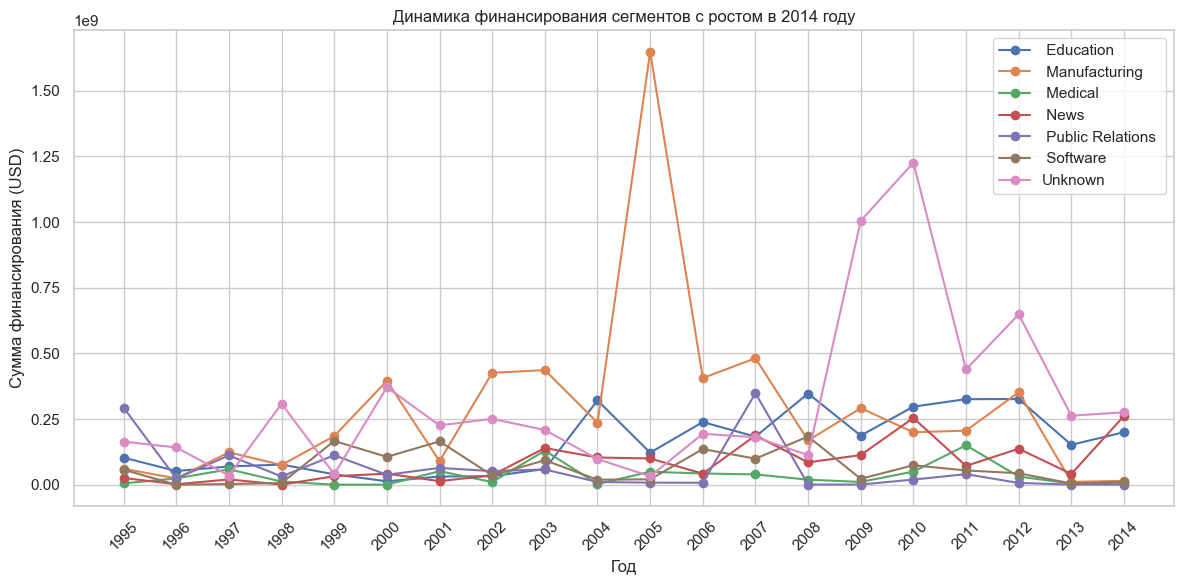

In [293]:
# Создаю столбец с годом
df_investments['year'] = pd.to_datetime(df_investments['founded_at']).dt.year

# Строю сводную таблицу
pivot_table = df_investments.pivot_table(
    values='funding_total_usd',
    index='year',
    columns='market',
    aggfunc='sum',
    fill_value=0
)

# Выбираю данные с 1995 года
pivot_table = pivot_table[pivot_table.index >= 1995]

# Отбираю сегменты с ростом в 2014 по сравнению с 2013
growth_markets = []
for market in pivot_table.columns:
    if 2013 in pivot_table.index and 2014 in pivot_table.index:
        funding_2013 = pivot_table.loc[2013, market]
        funding_2014 = pivot_table.loc[2014, market]
        if funding_2014 > funding_2013:
            growth_markets.append(market)

# Фильтрую таблицу по растущим сегментам
filtered_pivot = pivot_table[growth_markets]

# Вывожу сводную таблицу
print("Сводная таблица - финансирование по годам (USD):")
print(filtered_pivot)

plt.figure(figsize=(12, 6))

for market in growth_markets:
    plt.plot(filtered_pivot.index, filtered_pivot[market], label=market, marker='o')

plt.title('Динамика финансирования сегментов с ростом в 2014 году')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (USD)')
plt.legend()
plt.grid(True)
plt.xticks(filtered_pivot.index, rotation=45)
plt.tight_layout()
plt.show()

__Промежуточный вывод:__ мы вывели сегменты, которые показывают рост финансирования в 2014 году по отношению к 2013. Быстрый рост показывает только сегмент news. на самом деле, четкие выводы сделать нельзя. Ни один сегмент не показывает ярко выраженной динамики, чтобы мы могли выделить его из остальных. Есть обычная волатильность и взрывной рост с последующим падением в прошлые годы только одного сегмента - manufacturing.

## 10. Годовая динамика возвращенных средств по типам финансирования

Нам важно знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Нужно для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

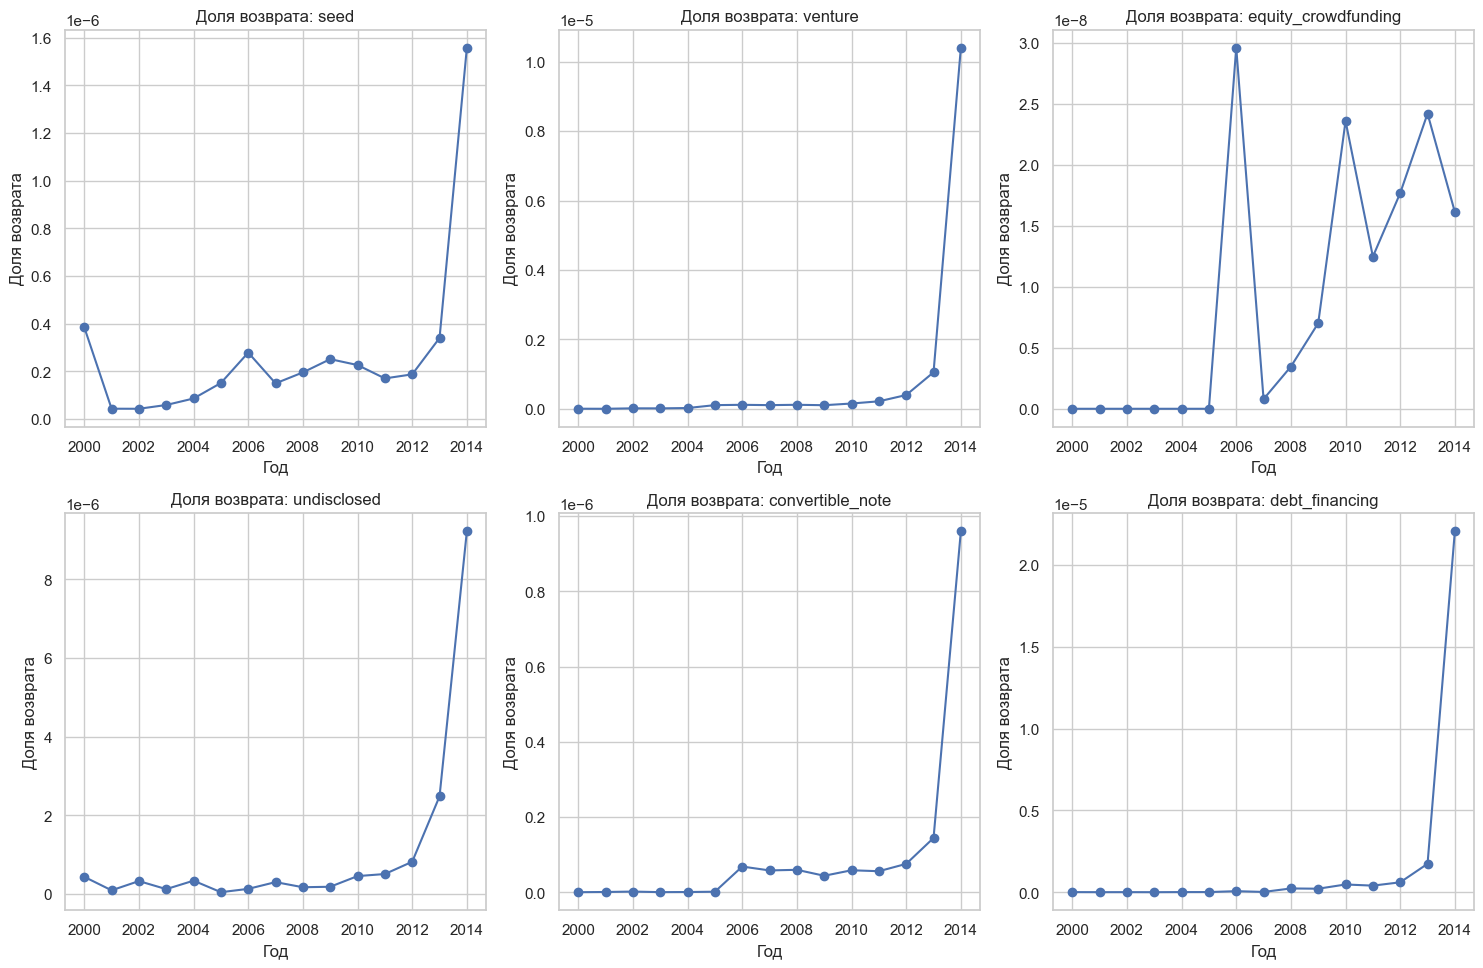

,founded_year,seed_return_ratio,venture_return_ratio,equity_crowdfunding_return_ratio,undisclosed_return_ratio,convertible_note_return_ratio,debt_financing_return_ratio,angel_return_ratio,grant_return_ratio,private_equity_return_ratio,post_ipo_equity_return_ratio,post_ipo_debt_return_ratio,secondary_market_return_ratio,product_crowdfunding_return_ratio
0,2000.0,0.000039,0.000000,0.000000,0.000043,0.000000,0.000001,0.000017,0.0,0.000000,0.000001,0.0,NaN,0.0
1,2001.0,0.000004,0.000000,0.000000,0.000009,0.000000,0.000000,0.000003,0.0,0.000000,0.000000,0.0,0.000002,0.0
2,2002.0,0.000004,0.000001,0.000000,0.000032,0.000000,0.000000,0.000014,0.0,0.000000,0.000000,0.0,0.000000,0.0
3,2003.0,0.000006,0.000001,0.000000,0.000012,0.000000,0.000000,0.000006,0.0,0.000000,0.000000,0.0,0.000002,0.0
4,2004.0,0.000009,0.000002,0.000000,0.000033,0.000000,0.000001,0.000015,0.0,0.000000,0.000000,0.0,NaN,0.0
5,2005.0,0.000015,0.000011,0.000000,0.000004,0.000000,0.000001,0.000022,0.0,0.000000,0.000000,0.0,0.000000,0.0
6,2006.0,0.000028,0.000012,0.000003,0.000013,0.000007,0.000006,0.000027,0.0,0.000000,0.000001,0.0,0.000000,0.0
7,2007.0,0.000015,0.000011,0.000000,0.000030,0.000006,0.000002,0.000062,0.0,0.000001,0.000004,0.0,0.000001,0.0
8,2008.0,0.000020,0.000012,0.000000,0.000017,0.000006,0.000023,0.000038,0.0,0.000003,0.000062,0.0,0.000004,0.0
9,2009.0,0.000025,0.000010,0.000001,0.000018,0.000004,0.000021,0.000031,0.0,0.000007,0.000023,0.0,NaN,0.0


In [294]:
# Суммирую привлеченные инвестиции по году основания
investment_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                     'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                     'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Группирую по году и суммируем инвестиции
investments_by_year = df_investments.groupby('founded_year')[investment_columns].sum().reset_index()

# Объединяю с данными о возвратах
merged_data = pd.merge(investments_by_year, df_returns, left_on='founded_year', right_on='year', how='inner', suffixes=('_invested', '_returned'))

# Рассчитываю долю возврата для каждого типа финансирования
for col in investment_columns:
    invested_col = col + '_invested'
    returned_col = col + '_returned'
    ratio_col = col + '_return_ratio'
    
    # Рассчитываю доли возврата с защитой от деления на ноль
    merged_data[ratio_col] = merged_data[returned_col] / (merged_data[invested_col] + 1e-60)
    
    # Заменяю аномальные значения на NaN
    merged_data[ratio_col] = merged_data[ratio_col].where(merged_data[ratio_col] <= 10)

plt.figure(figsize=(15, 10))
for i, col in enumerate(investment_columns[:6]):
    ratio_col = col + '_return_ratio'
    plt.subplot(2, 3, i+1)
    plt.plot(merged_data['founded_year'], merged_data[ratio_col], marker='o')
    plt.title(f'Доля возврата: {col}')
    plt.xlabel('Год')
    plt.ylabel('Доля возврата')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Вывожу таблицу с результатами
result_columns = ['founded_year'] + [col + '_return_ratio' for col in investment_columns]

# Умножаю на 100 для отображения в процентах и округляю до двух знаков
display_data = merged_data[result_columns].copy()
for col in display_data.columns:
    if col != 'founded_year':
        display_data[col] = (display_data[col] * 100).round(6)

display(display_data.head(10))

__Промежуточный вывод:__ самая высокая доля возврата пассивных инвестиций была в 2002 году. Доля возврата от венчурных инвестиций пришлась на 2014 год. Доля возврата инвестиций от краундфандинга была в 2006 году. Доля возврата от нераскрытого типа инвестиций не имеет четкой тенденции. Самая высокая доля в 2000 году с последующим резким снижением (возможно это были проекты, связанные с технологиями, которые потерпели крах в 2001 году). Сумма возвратов от долгового финансирования показывает сильную волатильность и вероятно зависит от экономических циклов и финансовых кризисов.

__Строю график, на котором отобразите нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.__

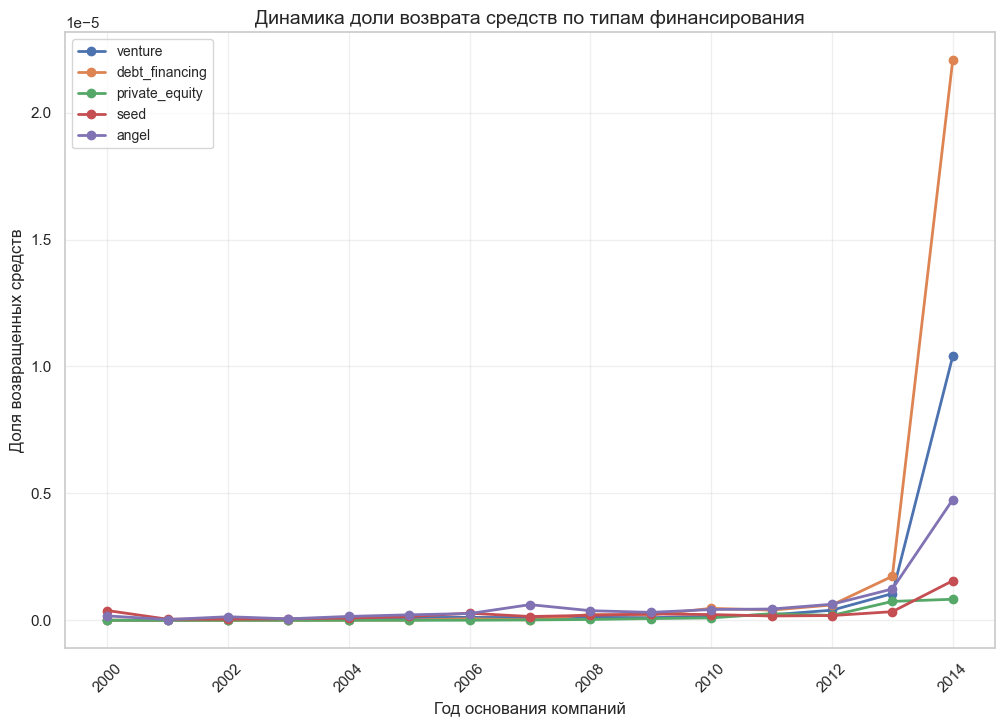

In [295]:
# Выбираю нужные типы финансирования
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 8))

for funding_type in selected_types:
    ratio_col = funding_type + '_return_ratio'
    plt.plot(merged_data['founded_year'], merged_data[ratio_col], 
             marker='o', linewidth=2, markersize=6, label=funding_type)

plt.title('Динамика доли возврата средств по типам финансирования', fontsize=14)
plt.xlabel('Год основания компаний', fontsize=12)
plt.ylabel('Доля возвращенных средств', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

__Промежуточный вывод:__ после 2012 года устойчивый рост финансирования наблюдается в сегментах: venture, debt_financing, angel. Сумма долгового финансирования (debt_financing) показывает макисмальный рост.

## 11. Итоговый вывод и рекомендации

В целом, после 2012 года хорошую динамику возврата показывают все сегменты, кроме equity_crowdfunding. Лучшую динамику доли возврата средств показывает сегмент debt_financing и venture. Суммарные объёмы возврата капитала у сегмента venture, это связано с бОльшими суммами, вложенными в этот сегмент. Venture лидирует по общему объёму привлеченных средств и имеет хорошую долю возврата капитала. Но стабильно лучшую динамику возврата капитала показывает сегмент debt_financing. Для дивесрификации вложений можно работать с этими двумя сегментами.

Были получены данные из двух датасетов. В процессе предобработки изменен тип данных в столбцах, связанных с датой и временем. Также приведены к численному типу столбцы funding_rounds, participants, founded_year. Удалили полные дубликаты и заполнили пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at. Подготовили данные к анализу.

Выводы согласуются между собой, но по ним сложно пронозировать динамику будущего поведения сегментов. Например, большой объём привлеченных средств в сегменте Venture может сигнализировать о "пузыре". лучше смотреть на устойчивую долю возврата инвестиций.